In [1]:
import os
try:
    path_initialized
except NameError:
    path_initialized = True
    os.chdir('..')

import numpy as np
from sympy.abc import x, y

# from qldpc import codes
import networkx as nx
import matplotlib.pyplot as plt
import stim
import pickle
import sinter
from copy import deepcopy
import scipy

import src.device as device
import src.plotting as plotter
import src.stim_dag as stim_dag

from src.RotatedSurfaceCode import RotatedSurfaceCode
from src.TileCode import TileCode
from src.HGPCode import HGPCode
from src.SHYPSCode import SHYPSCode
from src.RadialCode import RadialCode
from src.GBCode import GBCode
from src.HypercubeCode import HypercubeCode
from src.decoders import BPOSD

In [2]:
# Making codes
codes = []
code_types = []
code_nkds = []
code_data_coodes = []

ds_surface = [3, 5, 7, 9, 11]
for d in ds_surface:
    code = RotatedSurfaceCode(d)
    codes.append(code)
    code_types.append('Surface')
    code_nkds.append(code.compute_code_parameters())

nkds_tile = [(288,8,12), (288, 8, 14), (288, 18, 13), (512, 18, 19)]
for nkd in nkds_tile:
    code = TileCode.known_code(*nkd)
    codes.append(code)
    code_types.append('Tile')
    code_nkds.append(nkd)

rs_simplex = [3,4]
for r in rs_simplex:
    code = HGPCode.simplex_code(r)
    codes.append(code)
    code_types.append('Simplex')
    code_nkds.append(code.compute_code_parameters())
for r in rs_simplex:
    code = SHYPSCode(r)
    codes.append(code)
    code_types.append('SHYPS')
    code_nkds.append(code.compute_code_parameters())

rs_cube = [2,3]
for r in rs_cube:
    code = HypercubeCode(r)
    codes.append(code)
    code_types.append('Hypercube')
    code_nkds.append(code.compute_code_parameters())

lms = [
    (6,6),
    (15,3),
    (9,6),
    (12,6),
    (12,12),
]
orders = [
    (([3], [1,2]), ([1, 2], [3])),
    (([9], [1, 2]), ([2, 7], [0])),
    (([3], [1, 2]), ([1, 2], [3])),
    (([3], [1, 2]), ([1, 2], [3])),
    (([3], [2, 7]), ([1, 2], [3])),
]
nkds = [
    (72, 12, 6),
    (90, 8, 10),
    (108, 8, 10),
    (144, 12, 12),
    (288, 12, 18),
]
for (l,m),(a_ord,b_ord) in zip(lms, orders):
    code = GBCode(l, m, a_ord, b_ord)
    codes.append(code)
    code_types.append('BB')

code_nkds += nkds

rsds_radial = [(3,5,10), (3,8,12), (3,11,14), (4,6,12), (4,7,14), (4,8,16), (4,11,20)]
for r,s,d in rsds_radial:
    code = RadialCode(r,s,d)
    codes.append(code)
    code_types.append('Radial')
    code_nkds.append(code.compute_code_parameters())

for code in codes:
    assert len(code.qubit_coords) > 0, code

/home/jchadwick/projects/shuttle-ldpc/.venv/lib/python3.12/site-packages/numba/np/ufunc/parallel.py:373: NumbaWarning: The TBB threading layer requires TBB version 2021 update 6 or later i.e., TBB_INTERFACE_VERSION >= 12060. Found TBB_INTERFACE_VERSION = 12050. The TBB threading layer is disabled.
  warnings.warn(problem)


In [3]:
hwp = device.default_hwp
p = 1e-3
t2 = 1e-3
p_sh = 1e-3
error_params = device.error_params(p=p, T2=t2, p_sh=p_sh)
buffer = 3
basis = 'X'
schedules = dict()

for code, code_type, (n,k,d) in zip(codes, code_types, code_nkds):
    print(code_type, f'[[{n}, {k}, {d}]]...')
    xmax,ymax = 0,0
    data_coords = dict()
    for i in code.data_indices:
        x,y = code.qubit_coords[i]
        data_coords[i] = (x+buffer, y+buffer)
        xmax = max(xmax, x)
        ymax = max(ymax, y)
    dev = device.UnitCellDevice(xmax+2*buffer, ymax+2*buffer, hwp)
    
    rounds = d

    if code_type == 'Surface':
        sched = code.get_schedule(hwp, 'Z', rounds=rounds, refocus_shuttling_noise=True)
    else:
        sched = dev.compile_QEC_schedule(
            code,
            data_coords,
            code.check_cx_layers,
            rounds=rounds,
            use_highways=False,
            refocus_shuttle_noise=True,
            separate_X_Z=code_type != 'Surface',
        )
    schedules[(code_type, (n,k,d))] = sched

Surface [[9, 1, 3]]...
Surface [[25, 1, 5]]...
Surface [[49, 1, 7]]...
Surface [[81, 1, 9]]...
Surface [[121, 1, 11]]...
Tile [[288, 8, 12]]...
Tile [[288, 8, 14]]...
Tile [[288, 18, 13]]...
Tile [[512, 18, 19]]...
Simplex [[98, 18, 4]]...
Simplex [[450, 32, 8]]...
SHYPS [[49, 9, 4]]...
SHYPS [[225, 16, 8]]...
Hypercube [[36, 16, 4]]...
Optimizing 10 ancilla schedules..........
Optimizing 10 ancilla schedules..........
Hypercube [[216, 64, 8]]...
Optimizing 76 ancilla schedules............................................................................
Optimizing 76 ancilla schedules............................................................................
BB [[72, 12, 6]]...
BB [[90, 8, 10]]...
BB [[108, 8, 10]]...
BB [[144, 12, 12]]...
BB [[288, 12, 18]]...
Radial [[90, 8, 10]]...
Radial [[144, 8, 12]]...
Radial [[198, 8, 14]]...
Radial [[192, 18, 12]]...
Radial [[224, 18, 14]]...
Radial [[256, 18, 16]]...
Radial [[352, 18, 20]]...


In [4]:
code_ids = list(zip(code_types, code_nkds))

Multiple rounds detected; exiting early
Multiple rounds detected; exiting early
Multiple rounds detected; exiting early
Multiple rounds detected; exiting early
Multiple rounds detected; exiting early
Multiple rounds detected; exiting early
Multiple rounds detected; exiting early
Multiple rounds detected; exiting early
Multiple rounds detected; exiting early
Multiple rounds detected; exiting early
Multiple rounds detected; exiting early
Multiple rounds detected; exiting early
Multiple rounds detected; exiting early
Multiple rounds detected; exiting early
Multiple rounds detected; exiting early
Multiple rounds detected; exiting early
Multiple rounds detected; exiting early
Multiple rounds detected; exiting early
Multiple rounds detected; exiting early
Multiple rounds detected; exiting early
Multiple rounds detected; exiting early


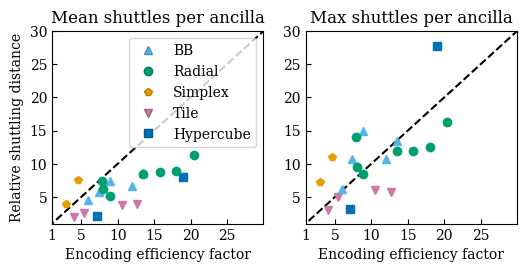

In [10]:
markerdict = {
    'BB':'^',
    'Radial':'o',
    'Simplex':'p',
    'Tile':'v',
    'Hypercube':'s'
}
colordict = {
    'BB':'C4',
    'Radial':'C2',
    'Simplex':'C3',
    'Tile':'C1',
    'Hypercube':'C0'
}

surface_dist = np.mean(list(device.ScheduleMetrics(schedules[('Surface', (9,1,3))]).qubit_distance_traveled.values()))

fig,ax = plt.subplots(1,2,figsize=(6,2.5))
plt.subplots_adjust(wspace=0.2)

ax[0].plot([-100, 100], [-100, 100], 'k--')
ax[1].plot([-100, 100], [-100, 100], 'k--')

for code_id,sched in schedules.items():
    code_type,(n,k,d) = code_id
    if code_type == 'SHYPS' or code_type == 'Surface':
        continue
    metrics = device.ScheduleMetrics(sched)
    shuttle_avg = np.mean(list(metrics.qubit_distance_traveled.values()))
    shuttle_max = max(list(metrics.qubit_distance_traveled.values()))
    enc_rate = k/n
    score = k*d**2/n
    ax[0].plot(score, shuttle_avg / surface_dist, color=colordict[code_type], marker=markerdict[code_type])
    ax[1].plot(score, shuttle_max / surface_dist, color=colordict[code_type], marker=markerdict[code_type])

for (code_type, marker) in markerdict.items():
    ax[0].plot([], [], color=colordict[code_type], marker=marker, linestyle='none', markeredgecolor=plotter.interpolate(colordict[code_type], 'k', 0.2), label=code_type)
ax[0].legend()
ax[0].set_xticks([1] + list(range(5,26,5)))
ax[0].set_xlim(1, 30)
ax[0].set_ylim(1, 30)
ax[0].set_xlabel('Encoding efficiency factor')
ax[0].set_ylabel('Relative shuttling distance')
ax[0].tick_params(direction='in')
ax[0].set_title('Mean shuttles per ancilla')

ax[1].set_xticks([1] + list(range(5,26,5)))
# ax[1].set_yticklabels([])
ax[1].set_xlim(1, 30)
ax[1].set_ylim(1, 30)
ax[1].set_xlabel('Encoding efficiency factor')
ax[1].tick_params(direction='in')
# ax[1].set_ylabel('Shuttling distance factor')
ax[1].set_title('Max shuttles per ancilla')

plt.savefig('notebooks/fig/13_shuttle_distance.pdf', bbox_inches='tight')